In [1]:
#### ------------------------------------------------------------------------------------------
#### author: Ranjan Barman, date: Jul 24, 2025 (modified for POST_NAT_BRCA)
#### Compute 12NPIFs from immune-only nuclei based on HoverNet prediction, using MPP = 0.248
#### Removes outliers for Major Axis and Minor Axis using IQR
#### --------------------------------------------------------------------------------------------

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Set working directory
_wpath_ = "/data/Lab_ruppin/Ranjan/HnE/"
os.makedirs(_wpath_, exist_ok=True)
os.chdir(_wpath_)
print("Working directory:", _wpath_)

# Define dataset name and output file path
dataset_name = "POST_NAT_BRCA"
input_folder = f"{dataset_name}/HoverNet/outputs/"
output_file_path = f"{dataset_name}/HoverNet/outputs/POST_NAT_BRCA_HoverNet_ImmuneOnly_NPIFs.csv"

# Columns to compute
columns_to_compute = ["Area", "Major Axis", "Minor Axis", "Perimeter", "Eccentricity", "Circularity"]

# MPP (microns per pixel) for 40X
MPP = 0.248

# Outlier removal function
def remove_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 3 * IQR
    upper = Q3 + 3 * IQR
    return df[(df[column] >= lower) & (df[column] <= upper)]

# Collect results
results = []

# Get all valid folders (exclude jobs, models)
postnat_folders = [f for f in os.listdir(input_folder) if os.path.isdir(os.path.join(input_folder, f)) and not f.startswith(("jobs", "models"))]

for slide_name in postnat_folders:
    feature_file = os.path.join(input_folder, slide_name, "features3", f"{slide_name}.csv")
    
    if not os.path.exists(feature_file):
        print(f"File not found: {feature_file}, skipping...")
        continue

    # Read immune-only feature CSV
    df = pd.read_csv(feature_file)

    # Unit conversion
    df["Area"] = df["Area"] * (MPP ** 2)
    df["Major Axis"] = df["Major Axis"] * MPP
    df["Minor Axis"] = df["Minor Axis"] * MPP
    df["Perimeter"] = df["Perimeter"] * MPP

    # Remove outliers for axes
    df = remove_outliers(df, "Major Axis")
    df = remove_outliers(df, "Minor Axis")

    # Compute mean and std
    mean_vals = df[columns_to_compute].mean()
    std_vals = df[columns_to_compute].std()

    results.append([slide_name] + mean_vals.tolist() + std_vals.tolist())

# Create dataframe
result_df = pd.DataFrame(
    results,
    columns=["Slide_Name"] + [f"Mean {col}" for col in columns_to_compute] + 
             [f"Std {col}" for col in columns_to_compute]
)

# Replace NaN or Inf with mean or zero
result_df.replace([np.inf, -np.inf], np.nan, inplace=True)
result_df.fillna(result_df.mean(numeric_only=True), inplace=True)
result_df.fillna(0, inplace=True)



Working directory: /data/Lab_ruppin/Ranjan/HnE/


In [2]:
result_df

,Slide_Name,Mean Area,Mean Major Axis,Mean Minor Axis,Mean Perimeter,Mean Eccentricity,Mean Circularity,Std Area,Std Major Axis,Std Minor Axis,Std Perimeter,Std Eccentricity,Std Circularity
0,99798_2068_tiles,6.234223,3.403043,2.504283,9.786657,0.632400,0.804226,2.142843,0.679794,0.419474,1.788070,0.149769,0.067493
1,102194_3173_tiles,5.959099,3.356364,2.411909,9.559795,0.648071,0.800894,2.342120,0.763055,0.446105,1.976320,0.149543,0.069787
2,102195_2284_tiles,6.529594,3.488981,2.520859,9.969473,0.644971,0.802914,2.681800,0.798375,0.502263,2.122120,0.151065,0.068466
3,99795_3386_tiles,5.755799,3.306024,2.375812,9.418714,0.652287,0.795610,2.281782,0.719547,0.461767,1.931150,0.148116,0.070694
4,99810_2730_tiles,5.599066,3.257257,2.346318,9.266034,0.644857,0.801757,2.177484,0.739026,0.417779,1.874792,0.151794,0.067143
...,...,...,...,...,...,...,...,...,...,...,...,...,...
91,102197_1224_tiles,6.747863,3.540054,2.579314,10.129803,0.638380,0.803758,2.790165,0.830980,0.503807,2.186750,0.148673,0.068585
92,102198_885_tiles,6.152919,3.452043,2.425781,9.752448,0.666296,0.795009,2.400605,0.783654,0.452314,2.032345,0.147115,0.070804
93,99861_4107_tiles,5.971473,3.386166,2.393547,9.609380,0.663013,0.789002,2.673258,0.809969,0.502907,2.183298,0.147002,0.073070
94,99809_4161_tiles,5.964404,3.357936,2.417000,9.580611,0.643983,0.799488,2.373240,0.786883,0.440628,2.033477,0.152995,0.071504


In [3]:
# Extract Slide_ID from Slide_Name (prefix before first underscore)
result_df['Slide_ID'] = result_df['Slide_Name'].str.split('_').str[0]

# Group by Slide_ID and average numeric columns
patient_avg_df = result_df.groupby('Slide_ID').mean(numeric_only=True)

# Save patient-level results
os.makedirs(os.path.dirname(output_file_path), exist_ok=True)
patient_avg_df.to_csv(output_file_path)
print(f"Converted results saved to: {output_file_path}")

patient_avg_df




Converted results saved to: POST_NAT_BRCA/HoverNet/outputs/POST_NAT_BRCA_HoverNet_ImmuneOnly_NPIFs.csv


,Mean Area,Mean Major Axis,Mean Minor Axis,Mean Perimeter,Mean Eccentricity,Mean Circularity,Std Area,Std Major Axis,Std Minor Axis,Std Perimeter,Std Eccentricity,Std Circularity
Slide_ID,,,,,,,,,,,,
102174,6.557896,3.516342,2.532950,10.044706,0.648214,0.799813,2.499415,0.772862,0.461205,2.030543,0.148594,0.071329
102175,7.089205,3.675773,2.591339,10.438079,0.667644,0.789652,3.196445,0.896005,0.582451,2.449476,0.144765,0.074695
102176,7.427602,3.769212,2.647163,10.700085,0.667431,0.788370,3.308215,0.928073,0.578283,2.488800,0.147873,0.074562
102177,7.117124,3.605087,2.651451,10.375197,0.633235,0.802863,3.246423,0.881212,0.570533,2.383281,0.146774,0.066823
102178,6.221815,3.458331,2.445894,9.804666,0.660917,0.795985,2.418025,0.786607,0.449509,2.039220,0.147140,0.072611
...,...,...,...,...,...,...,...,...,...,...,...,...
99861,5.971473,3.386166,2.393547,9.609380,0.663013,0.789002,2.673258,0.809969,0.502907,2.183298,0.147002,0.073070
99862,5.984373,3.422535,2.378411,9.642456,0.671194,0.791237,2.460852,0.827918,0.447332,2.123904,0.148302,0.075380
99866,5.427061,3.208752,2.340398,9.213919,0.638720,0.793337,1.797848,0.640102,0.387258,1.696596,0.149864,0.077196


In [4]:
patient_avg_df.describe()

,Mean Area,Mean Major Axis,Mean Minor Axis,Mean Perimeter,Mean Eccentricity,Mean Circularity,Std Area,Std Major Axis,Std Minor Axis,Std Perimeter,Std Eccentricity,Std Circularity
count,96.000000,96.000000,96.000000,96.000000,96.000000,96.000000,96.000000,96.000000,96.000000,96.000000,96.000000,96.000000
mean,6.289848,3.431196,2.476735,9.811504,0.645164,0.797579,2.564064,0.787733,0.481183,2.087579,0.150467,0.070339
std,0.709251,0.161978,0.139764,0.501998,0.017639,0.006610,0.443458,0.075779,0.066077,0.226007,0.003496,0.003901
min,5.323844,3.141462,2.295575,9.076602,0.548981,0.783735,1.797848,0.625146,0.387258,1.659292,0.144221,0.056246
25%,5.865759,3.331116,2.380875,9.466934,0.636089,0.793676,2.275166,0.732341,0.442019,1.934030,0.148056,0.068066
50%,6.126239,3.410191,2.443060,9.707799,0.645731,0.798041,2.520636,0.787737,0.474111,2.067744,0.149863,0.070499
75%,6.603843,3.513822,2.534315,10.046920,0.657030,0.801822,2.733635,0.838849,0.503738,2.214581,0.152775,0.072624
max,9.245371,3.989898,3.140820,11.770472,0.675046,0.820983,4.145479,0.974017,0.754622,2.785051,0.162378,0.079735


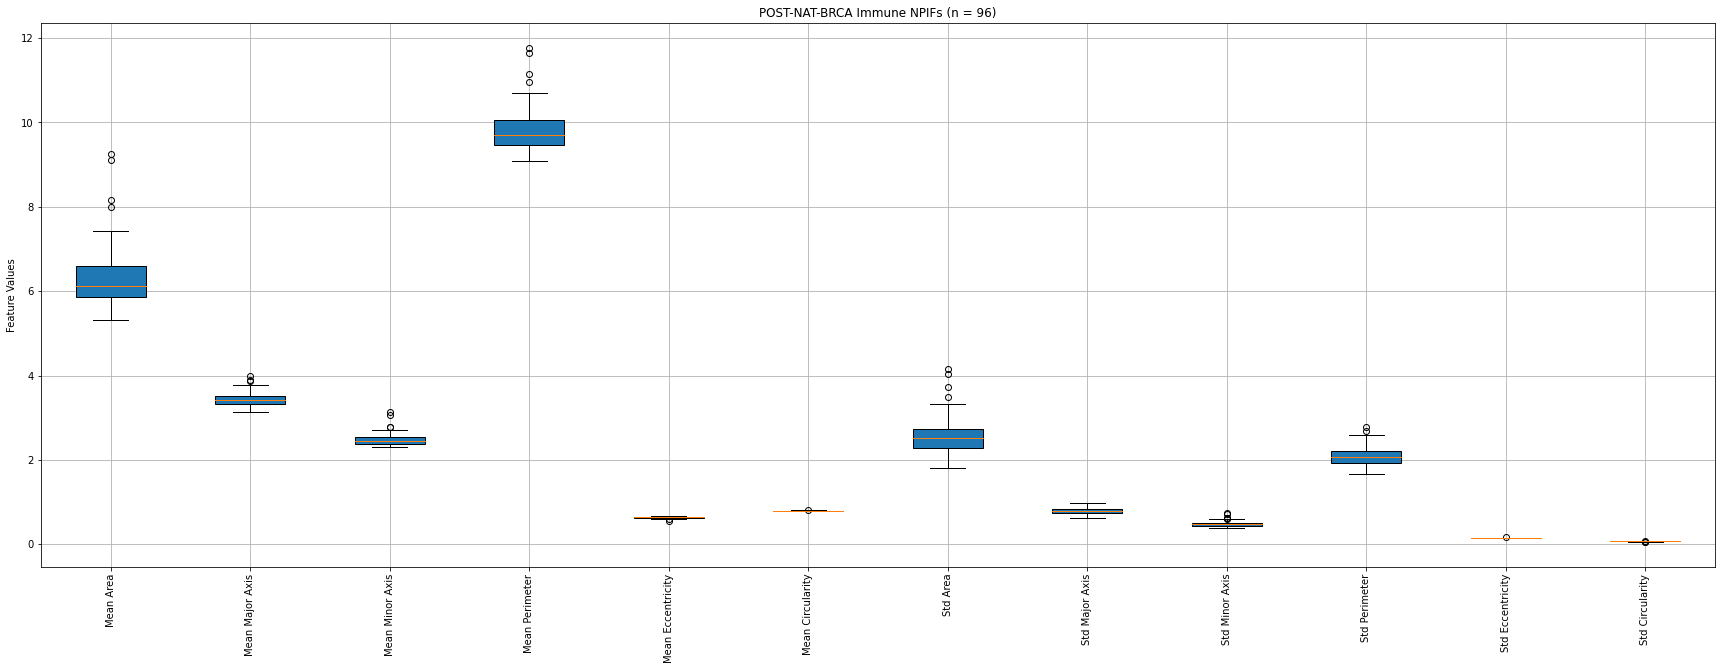

In [5]:
# Import required library
import matplotlib.pyplot as plt

# Plot boxplots for POST_NAT_BRCA NPIFs
n_samples = patient_avg_df.shape[0]
plt.figure(figsize=(30, 10))
plt.boxplot(patient_avg_df.values, labels=patient_avg_df.columns, vert=True, patch_artist=True)
plt.xticks(rotation=90)
plt.title(f"POST-NAT-BRCA Immune NPIFs (n = {n_samples})")
plt.ylabel("Feature Values")
plt.grid(True)
plt.show()